# Домашнее задание к семинарам 08-09 (HW08-09)

## Тема: PyTorch 101 b основы оптимизации обучения.
Часть S08: MLP b регуляризация (Dropout, BatchNorm, EarlyStopping).

Часть S09: learning rate диагностика, Adam vs SGD+momentum, weight decay.

## 1. Импорты, фиксирование seed и устройство

In [5]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

torch version: 2.10.0
torchvision version: 0.25.0


### Фиксируем seed для воспроизводимости результатов

In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("Seed fixed:", SEED)

Seed fixed: 42


In [7]:
#Определяем устройство& GPU, если доступен, иначе CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 2. Данные и DataLoader


В работе используется датасет **`EMNIST(split="balanced")`** из `torchvision.datasets`.

In [10]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [11]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset_full = datasets.EMNIST(
    root="./data",
    split="balanced",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.EMNIST(
    root="./data",
    split="balanced",
    train=False,
    download=True,
    transform=transform
)

print("Train dataset size:", len(train_dataset_full))
print("Test dataset size:", len(test_dataset))

100.0%


Train dataset size: 112800
Test dataset size: 18800


Разделение train / validation

In [12]:
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size
generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=generator
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 90240
Validation size: 22560
Test size: 18800


DataLoader

In [13]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders created")

DataLoaders created


Sanity-check batch

In [14]:
x, y = next(iter(train_loader))

print("x shape:", x.shape)
print("y shape:", y.shape)

print("x dtype:", x.dtype)
print("y dtype:", y.dtype)

print("x min:", x.min().item())
print("x max:", x.max().item())

x shape: torch.Size([128, 1, 28, 28])
y shape: torch.Size([128])
x dtype: torch.float32
y dtype: torch.int64
x min: 0.0
x max: 1.0


Проверка device

In [15]:
x = x.to(device)
y = y.to(device)

print("x device:", x.device)
print("y device:", y.device)

x device: cpu
y device: cpu


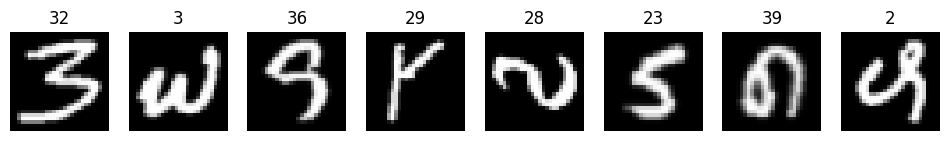

In [16]:
fig, axes = plt.subplots(1, 8, figsize=(12,3))

for i, ax in enumerate(axes):
    ax.imshow(x[i].cpu().squeeze(), cmap="gray")
    ax.set_title(int(y[i].cpu()))
    ax.axis("off")

plt.show()

#### Модель MLP и цикл обучения

In [17]:
import torch.nn as nn

NUM_CLASSES = 47

class MLPClassifier(nn.Module):
    def __init__(self, input_size=28 * 28, hidden1=256, hidden2=128, num_classes=NUM_CLASSES):
        super().__init__()
        
        self.flatten = nn.Flatten()
        
        # Полносвязные слои
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, num_classes)
        
        # Функция активации
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: [batch_size, 1, 28, 28]
        x = self.flatten(x)  
        x = self.fc1(x)    
        x = self.relu(x)
        x = self.fc2(x)    
        x = self.relu(x)
        x = self.fc3(x)    
        return x         

In [18]:
model = MLPClassifier().to(device)
print(model)

MLPClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=47, bias=True)
  (relu): ReLU()
)


loss и optimizer

In [19]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

accuracy

In [20]:
def accuracy_fn(logits, y_true):
    preds = torch.argmax(logits, dim=1)
    correct = (preds == y_true).sum().item()
    total = y_true.size(0)
    return correct / total

Проверка на одном батче

In [21]:
x_batch, y_batch = next(iter(train_loader))

x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

logits = model(x_batch)

print("Input shape:", x_batch.shape)
print("Target shape:", y_batch.shape)
print("Logits shape:", logits.shape)

Input shape: torch.Size([128, 1, 28, 28])
Target shape: torch.Size([128])
Logits shape: torch.Size([128, 47])


Проверка loss и accuracy на одном батче

In [22]:
loss = criterion(logits, y_batch)
acc = accuracy_fn(logits, y_batch)

print("Loss on one batch:", loss.item())
print("Accuracy on one batch:", acc)

Loss on one batch: 3.8560516834259033
Accuracy on one batch: 0.03125


Проверка на одном батче показала, что размеры входа, выхода и целевых меток согласованы корректно.

Реализация функций `train_one_epoch(...)` и `evaluate(...)`

In [ ]:
import torch

def accuracy_fn(logits, y_true):

    preds = torch.argmax(logits, dim=1)
    correct = (preds == y_true).sum().item()
    total = y_true.size(0)
    return correct / total


def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x_batch, y_batch in dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(x_batch)

        loss = criterion(logits, y_batch)


        loss.backward()


        optimizer.step()

 
        total_loss += loss.item() * x_batch.size(0)

        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == y_batch).sum().item()
        total_samples += y_batch.size(0)

    average_loss = total_loss / total_samples
    average_acc = total_correct / total_samples

    return average_loss, average_acc


def evaluate(model, dataloader, criterion, device):

    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0


    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * x_batch.size(0)

            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == y_batch).sum().item()
            total_samples += y_batch.size(0)

    average_loss = total_loss / total_samples
    average_acc = total_correct / total_samples

    return average_loss, average_acc

Логирование истории обучения

In [24]:
NUM_EPOCHS = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_acc = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

Epoch [1/10] | train_loss=1.3052, train_acc=0.6330 | val_loss=0.8505, val_acc=0.7406
Epoch [2/10] | train_loss=0.7149, train_acc=0.7769 | val_loss=0.6578, val_acc=0.7937
Epoch [3/10] | train_loss=0.5762, train_acc=0.8123 | val_loss=0.5769, val_acc=0.8167
Epoch [4/10] | train_loss=0.5055, train_acc=0.8310 | val_loss=0.5370, val_acc=0.8277
Epoch [5/10] | train_loss=0.4581, train_acc=0.8452 | val_loss=0.5316, val_acc=0.8221
Epoch [6/10] | train_loss=0.4241, train_acc=0.8534 | val_loss=0.5080, val_acc=0.8335
Epoch [7/10] | train_loss=0.3947, train_acc=0.8618 | val_loss=0.4990, val_acc=0.8370
Epoch [8/10] | train_loss=0.3733, train_acc=0.8677 | val_loss=0.4951, val_acc=0.8362
Epoch [9/10] | train_loss=0.3489, train_acc=0.8734 | val_loss=0.4926, val_acc=0.8410
Epoch [10/10] | train_loss=0.3319, train_acc=0.8797 | val_loss=0.4999, val_acc=0.8384


Построение графиков истории

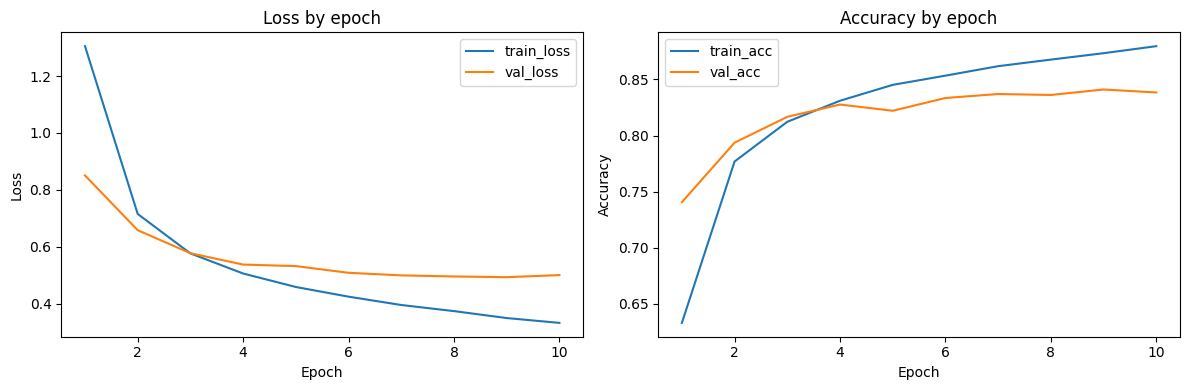

In [25]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss by epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train_acc")
plt.plot(epochs, history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy by epoch")
plt.legend()

plt.tight_layout()
plt.show()

## 3. Эксперименты

## 3.1. Часть A (S08): регуляризация и переобучение

### 1. Подготовка папок для артефактов

In [27]:
import os
import json
import copy
import csv

ARTIFACTS_DIR = "./artifacts"
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, "figures")

os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

RUNS_CSV_PATH = os.path.join(ARTIFACTS_DIR, "runs.csv")
BEST_MODEL_PATH = os.path.join(ARTIFACTS_DIR, "best_model.pt")
BEST_CONFIG_PATH = os.path.join(ARTIFACTS_DIR, "best_config.json")

### 2. Более гибкая модель MLP

In [29]:
import torch
import torch.nn as nn

NUM_CLASSES = 47

class MLPClassifier(nn.Module):
    def __init__(
        self,
        input_size=28 * 28,
        hidden_sizes=(512, 256, 128),
        num_classes=NUM_CLASSES,
        activation_name="ReLU",
        dropout_p=0.0,
        use_batchnorm=False
    ):
        super().__init__()

        self.flatten = nn.Flatten()

        layers = []
        in_features = input_size

        if activation_name == "ReLU":
            activation_cls = nn.ReLU
        else:
            raise ValueError(f"Unsupported activation: {activation_name}")

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(in_features, hidden_size))

            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))

            layers.append(activation_cls())

            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))

            in_features = hidden_size

        layers.append(nn.Linear(in_features, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        x = self.network(x)
        return x  # logits

### 3. Функции обучения и оценки

In [30]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x_batch, y_batch in dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(x_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)
        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == y_batch).sum().item()
        total_samples += y_batch.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * x_batch.size(0)
            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == y_batch).sum().item()
            total_samples += y_batch.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

### 4. EarlyStopping

In [31]:
class EarlyStopping:
    def __init__(self, patience=4, mode="max", min_delta=0.0):
        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta

        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, current_score):
        if self.best_score is None:
            self.best_score = current_score
            return False

        if self.mode == "max":
            improved = current_score > self.best_score + self.min_delta
        elif self.mode == "min":
            improved = current_score < self.best_score - self.min_delta
        else:
            raise ValueError("mode must be 'max' or 'min'")

        if improved:
            self.best_score = current_score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

        return self.should_stop

### 5. Универсальный запуск одного эксперимента

In [32]:
def run_experiment(
    experiment_id,
    dataset_name,
    seed,
    model_config,
    optimizer_name,
    lr,
    train_loader,
    val_loader,
    device,
    num_epochs=15,
    momentum=0.0,
    weight_decay=0.0,
    use_early_stopping=False,
    early_stopping_patience=4
):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = MLPClassifier(**model_config).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay
        )
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = -1.0
    best_val_loss = float("inf")
    best_epoch = 0
    best_state_dict = copy.deepcopy(model.state_dict())

    early_stopper = None
    if use_early_stopping:
        early_stopper = EarlyStopping(
            patience=early_stopping_patience,
            mode="max"
        )

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state_dict = copy.deepcopy(model.state_dict())

        print(
            f"{experiment_id} | "
            f"Epoch [{epoch + 1}/{num_epochs}] | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

        if early_stopper is not None:
            stop = early_stopper.step(val_acc)
            if stop:
                print(f"Early stopping triggered at epoch {epoch + 1}")
                break

    model.load_state_dict(best_state_dict)

    result = {
        "experiment_id": experiment_id,
        "dataset": dataset_name,
        "seed": seed,
        "model_summary": (
            f"hidden={model_config['hidden_sizes']}; "
            f"act={model_config.get('activation_name', 'ReLU')}; "
            f"dropout={model_config.get('dropout_p', 0.0)}; "
            f"batchnorm={model_config.get('use_batchnorm', False)}"
        ),
        "optimizer": optimizer_name,
        "lr": lr,
        "momentum": momentum if optimizer_name == "SGD" else 0.0,
        "weight_decay": weight_decay,
        "epochs_trained": len(history["train_loss"]),
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch
    }

    return model, history, result

### 6. Функция записи в runs.csv

In [33]:
def append_run_to_csv(csv_path, run_result):
    file_exists = os.path.exists(csv_path)

    fieldnames = [
        "experiment_id",
        "dataset",
        "seed",
        "model_summary",
        "optimizer",
        "lr",
        "momentum",
        "weight_decay",
        "epochs_trained",
        "best_val_accuracy",
        "best_val_loss",
        "best_epoch"
    ]

    with open(csv_path, mode="a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)

        if not file_exists:
            writer.writeheader()

        writer.writerow(run_result)

In [34]:
if os.path.exists(RUNS_CSV_PATH):
    os.remove(RUNS_CSV_PATH)

### 7. Конфиги для E1, E2, E3

In [35]:
DATASET_NAME = "EMNIST"
SEED = 42
BASE_LR = 1e-3
BASE_EPOCHS = 15

base_hidden = (512, 256, 128)

config_e1 = {
    "input_size": 28 * 28,
    "hidden_sizes": base_hidden,
    "num_classes": NUM_CLASSES,
    "activation_name": "ReLU",
    "dropout_p": 0.0,
    "use_batchnorm": False
}

config_e2 = {
    "input_size": 28 * 28,
    "hidden_sizes": base_hidden,
    "num_classes": NUM_CLASSES,
    "activation_name": "ReLU",
    "dropout_p": 0.3,
    "use_batchnorm": False
}

config_e3 = {
    "input_size": 28 * 28,
    "hidden_sizes": base_hidden,
    "num_classes": NUM_CLASSES,
    "activation_name": "ReLU",
    "dropout_p": 0.0,
    "use_batchnorm": True
}

### 8. Запуск E1, E2, E3

In [36]:
if os.path.exists(RUNS_CSV_PATH):
    os.remove(RUNS_CSV_PATH)

model_e1, history_e1, result_e1 = run_experiment(
    experiment_id="E1",
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_config=config_e1,
    optimizer_name="Adam",
    lr=BASE_LR,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=BASE_EPOCHS
)
append_run_to_csv(RUNS_CSV_PATH, result_e1)

model_e2, history_e2, result_e2 = run_experiment(
    experiment_id="E2",
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_config=config_e2,
    optimizer_name="Adam",
    lr=BASE_LR,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=BASE_EPOCHS
)
append_run_to_csv(RUNS_CSV_PATH, result_e2)

model_e3, history_e3, result_e3 = run_experiment(
    experiment_id="E3",
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_config=config_e3,
    optimizer_name="Adam",
    lr=BASE_LR,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=BASE_EPOCHS
)
append_run_to_csv(RUNS_CSV_PATH, result_e3)

E1 | Epoch [1/15] | train_loss=1.1530, train_acc=0.6611 | val_loss=0.7011, val_acc=0.7790
E1 | Epoch [2/15] | train_loss=0.6035, train_acc=0.8006 | val_loss=0.5970, val_acc=0.8019
E1 | Epoch [3/15] | train_loss=0.4976, train_acc=0.8300 | val_loss=0.5362, val_acc=0.8224
E1 | Epoch [4/15] | train_loss=0.4336, train_acc=0.8484 | val_loss=0.4955, val_acc=0.8378
E1 | Epoch [5/15] | train_loss=0.3900, train_acc=0.8606 | val_loss=0.4812, val_acc=0.8402
E1 | Epoch [6/15] | train_loss=0.3555, train_acc=0.8703 | val_loss=0.4789, val_acc=0.8434
E1 | Epoch [7/15] | train_loss=0.3264, train_acc=0.8775 | val_loss=0.4737, val_acc=0.8443
E1 | Epoch [8/15] | train_loss=0.3004, train_acc=0.8845 | val_loss=0.4915, val_acc=0.8430
E1 | Epoch [9/15] | train_loss=0.2812, train_acc=0.8911 | val_loss=0.4911, val_acc=0.8464
E1 | Epoch [10/15] | train_loss=0.2605, train_acc=0.8982 | val_loss=0.4865, val_acc=0.8521
E1 | Epoch [11/15] | train_loss=0.2460, train_acc=0.9018 | val_loss=0.5136, val_acc=0.8419
E1 | Epo

### 9. Выбор лучшего из E2/E3 для E4

In [37]:
candidate_results = [
    ("E2", config_e2, result_e2),
    ("E3", config_e3, result_e3),
]

best_candidate_id, best_candidate_config, best_candidate_result = max(
    candidate_results,
    key=lambda x: x[2]["best_val_accuracy"]
)

print("Best candidate for E4:", best_candidate_id)
print("Best val accuracy:", best_candidate_result["best_val_accuracy"])

Best candidate for E4: E3
Best val accuracy: 0.8574024822695036


### 10. Запуск E4 с EarlyStopping

In [38]:
model_e4, history_e4, result_e4 = run_experiment(
    experiment_id="E4",
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_config=best_candidate_config,
    optimizer_name="Adam",
    lr=BASE_LR,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=30,       
    use_early_stopping=True,
    early_stopping_patience=4
)
append_run_to_csv(RUNS_CSV_PATH, result_e4)

E4 | Epoch [1/30] | train_loss=0.8922, train_acc=0.7498 | val_loss=0.5450, val_acc=0.8165
E4 | Epoch [2/30] | train_loss=0.4867, train_acc=0.8329 | val_loss=0.4869, val_acc=0.8368
E4 | Epoch [3/30] | train_loss=0.4129, train_acc=0.8550 | val_loss=0.4478, val_acc=0.8444
E4 | Epoch [4/30] | train_loss=0.3638, train_acc=0.8689 | val_loss=0.4425, val_acc=0.8489
E4 | Epoch [5/30] | train_loss=0.3307, train_acc=0.8765 | val_loss=0.4379, val_acc=0.8489
E4 | Epoch [6/30] | train_loss=0.3054, train_acc=0.8848 | val_loss=0.4464, val_acc=0.8477
E4 | Epoch [7/30] | train_loss=0.2809, train_acc=0.8917 | val_loss=0.4308, val_acc=0.8533
E4 | Epoch [8/30] | train_loss=0.2616, train_acc=0.8978 | val_loss=0.4473, val_acc=0.8531
E4 | Epoch [9/30] | train_loss=0.2454, train_acc=0.9030 | val_loss=0.4471, val_acc=0.8533
E4 | Epoch [10/30] | train_loss=0.2299, train_acc=0.9086 | val_loss=0.4484, val_acc=0.8557
E4 | Epoch [11/30] | train_loss=0.2167, train_acc=0.9125 | val_loss=0.4603, val_acc=0.8524
E4 | Epo

### 11. Сохранение лучшей модели

In [39]:
torch.save(model_e4.state_dict(), BEST_MODEL_PATH)
print("Saved best model to:", BEST_MODEL_PATH)

Saved best model to: ./artifacts/best_model.pt


### 12. Сохранение best_config.json

In [40]:
best_config = {
    "experiment_id": "E4",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "model_config": best_candidate_config,
    "optimizer": "Adam",
    "lr": BASE_LR,
    "momentum": 0.0,
    "weight_decay": 0.0,
    "early_stopping": {
        "enabled": True,
        "patience": 4
    },
    "epochs_trained": result_e4["epochs_trained"],
    "best_val_accuracy": result_e4["best_val_accuracy"],
    "best_val_loss": result_e4["best_val_loss"]
}

with open(BEST_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=4)

print("Saved best config to:", BEST_CONFIG_PATH)

Saved best config to: ./artifacts/best_config.json


### 13. График curves_best.png

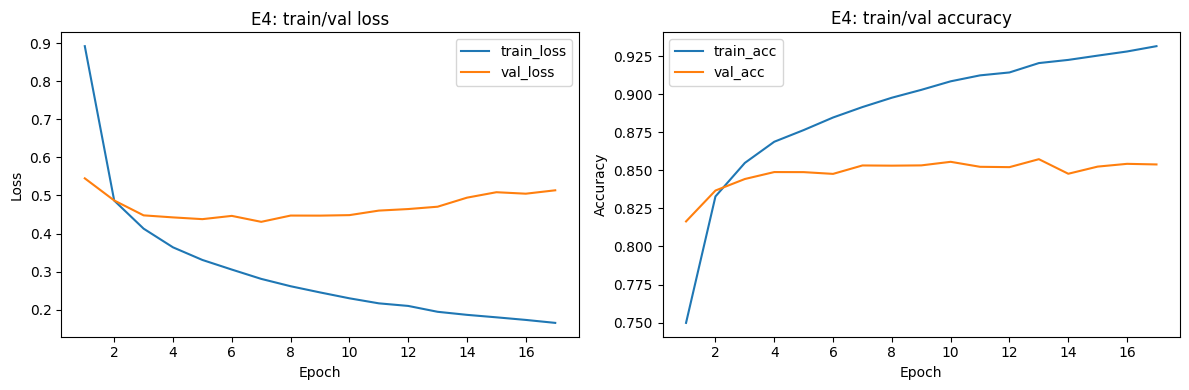

In [41]:
import matplotlib.pyplot as plt

epochs_e4 = range(1, len(history_e4["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_e4, history_e4["train_loss"], label="train_loss")
plt.plot(epochs_e4, history_e4["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("E4: train/val loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_e4, history_e4["train_acc"], label="train_acc")
plt.plot(epochs_e4, history_e4["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("E4: train/val accuracy")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "curves_best.png"), dpi=150, bbox_inches="tight")
plt.show()

### 14. Финальная оценка на test

In [42]:
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)

print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

Final test loss: 0.4978
Final test accuracy: 0.8527


## 3.2. Часть B (S09): LR, оптимизаторы, weight decay

### 1. Зафиксировать архитектуру из E4

In [43]:
fixed_arch_config = best_candidate_config
print(fixed_arch_config)

{'input_size': 784, 'hidden_sizes': (512, 256, 128), 'num_classes': 47, 'activation_name': 'ReLU', 'dropout_p': 0.0, 'use_batchnorm': True}


### 2. O1 - слишком большой learning rate

In [44]:
model_o1, history_o1, result_o1 = run_experiment(
    experiment_id="O1",
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_config=fixed_arch_config,
    optimizer_name="Adam",
    lr=1e-1,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=6
)
append_run_to_csv(RUNS_CSV_PATH, result_o1)

O1 | Epoch [1/6] | train_loss=1.0871, train_acc=0.6697 | val_loss=0.7583, val_acc=0.7579
O1 | Epoch [2/6] | train_loss=0.7344, train_acc=0.7635 | val_loss=0.6982, val_acc=0.7715
O1 | Epoch [3/6] | train_loss=0.6591, train_acc=0.7841 | val_loss=0.6656, val_acc=0.7851
O1 | Epoch [4/6] | train_loss=0.6058, train_acc=0.7983 | val_loss=0.5952, val_acc=0.8113
O1 | Epoch [5/6] | train_loss=0.5668, train_acc=0.8113 | val_loss=0.5932, val_acc=0.8108
O1 | Epoch [6/6] | train_loss=0.5455, train_acc=0.8154 | val_loss=0.5951, val_acc=0.8094


### 3. O2 - слишком маленький learning rate

In [45]:
model_o2, history_o2, result_o2 = run_experiment(
    experiment_id="O2",
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_config=fixed_arch_config,
    optimizer_name="Adam",
    lr=1e-5,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=6
)
append_run_to_csv(RUNS_CSV_PATH, result_o2)

O2 | Epoch [1/6] | train_loss=3.3254, train_acc=0.2542 | val_loss=2.9104, val_acc=0.4466
O2 | Epoch [2/6] | train_loss=2.6837, train_acc=0.5124 | val_loss=2.4792, val_acc=0.5656
O2 | Epoch [3/6] | train_loss=2.3229, train_acc=0.5961 | val_loss=2.1736, val_acc=0.6262
O2 | Epoch [4/6] | train_loss=2.0474, train_acc=0.6431 | val_loss=1.9260, val_acc=0.6607
O2 | Epoch [5/6] | train_loss=1.8218, train_acc=0.6738 | val_loss=1.7185, val_acc=0.6840
O2 | Epoch [6/6] | train_loss=1.6330, train_acc=0.6971 | val_loss=1.5460, val_acc=0.7052


### 4. O3 - SGD + momentum + weight decay

In [46]:
model_o3, history_o3, result_o3 = run_experiment(
    experiment_id="O3",
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_config=fixed_arch_config,
    optimizer_name="SGD",
    lr=1e-2,
    momentum=0.9,
    weight_decay=1e-4,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=12
)
append_run_to_csv(RUNS_CSV_PATH, result_o3)

O3 | Epoch [1/12] | train_loss=1.0086, train_acc=0.7247 | val_loss=0.5919, val_acc=0.8104
O3 | Epoch [2/12] | train_loss=0.5152, train_acc=0.8275 | val_loss=0.5038, val_acc=0.8318
O3 | Epoch [3/12] | train_loss=0.4300, train_acc=0.8513 | val_loss=0.4702, val_acc=0.8401
O3 | Epoch [4/12] | train_loss=0.3778, train_acc=0.8665 | val_loss=0.4532, val_acc=0.8463
O3 | Epoch [5/12] | train_loss=0.3419, train_acc=0.8763 | val_loss=0.4521, val_acc=0.8466
O3 | Epoch [6/12] | train_loss=0.3147, train_acc=0.8828 | val_loss=0.4561, val_acc=0.8436
O3 | Epoch [7/12] | train_loss=0.2904, train_acc=0.8917 | val_loss=0.4427, val_acc=0.8524
O3 | Epoch [8/12] | train_loss=0.2708, train_acc=0.8970 | val_loss=0.4525, val_acc=0.8474
O3 | Epoch [9/12] | train_loss=0.2520, train_acc=0.9035 | val_loss=0.4514, val_acc=0.8499
O3 | Epoch [10/12] | train_loss=0.2367, train_acc=0.9079 | val_loss=0.4584, val_acc=0.8486
O3 | Epoch [11/12] | train_loss=0.2228, train_acc=0.9133 | val_loss=0.4724, val_acc=0.8449
O3 | Epo

### 5. Построение графика curves_lr_extremes.png

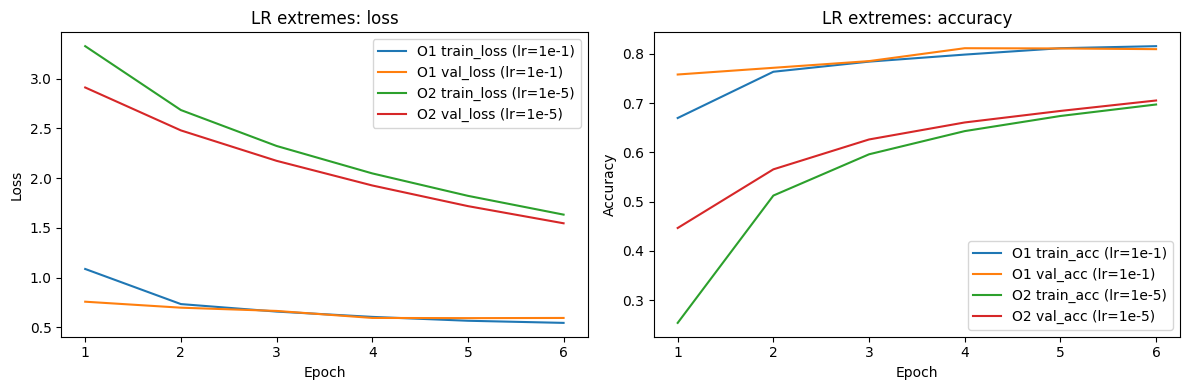

In [47]:
import matplotlib.pyplot as plt
import os

epochs_o1 = range(1, len(history_o1["train_loss"]) + 1)
epochs_o2 = range(1, len(history_o2["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

# График loss
plt.subplot(1, 2, 1)
plt.plot(epochs_o1, history_o1["train_loss"], label="O1 train_loss (lr=1e-1)")
plt.plot(epochs_o1, history_o1["val_loss"], label="O1 val_loss (lr=1e-1)")
plt.plot(epochs_o2, history_o2["train_loss"], label="O2 train_loss (lr=1e-5)")
plt.plot(epochs_o2, history_o2["val_loss"], label="O2 val_loss (lr=1e-5)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LR extremes: loss")
plt.legend()

# График accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_o1, history_o1["train_acc"], label="O1 train_acc (lr=1e-1)")
plt.plot(epochs_o1, history_o1["val_acc"], label="O1 val_acc (lr=1e-1)")
plt.plot(epochs_o2, history_o2["train_acc"], label="O2 train_acc (lr=1e-5)")
plt.plot(epochs_o2, history_o2["val_acc"], label="O2 val_acc (lr=1e-5)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LR extremes: accuracy")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "curves_lr_extremes.png"), dpi=150, bbox_inches="tight")
plt.show()

In [49]:
for r in [result_o1, result_o2, result_o3]:
    print(
        f"{r['experiment_id']} | optimizer={r['optimizer']} | "
        f"lr={r['lr']} | momentum={r['momentum']} | wd={r['weight_decay']} | "
        f"best_val_acc={r['best_val_accuracy']:.4f} | best_val_loss={r['best_val_loss']:.4f}"
    )

O1 | optimizer=Adam | lr=0.1 | momentum=0.0 | wd=0.0 | best_val_acc=0.8113 | best_val_loss=0.5952
O2 | optimizer=Adam | lr=1e-05 | momentum=0.0 | wd=0.0 | best_val_acc=0.7052 | best_val_loss=1.5460
O3 | optimizer=SGD | lr=0.01 | momentum=0.9 | wd=0.0001 | best_val_acc=0.8524 | best_val_loss=0.4427


Проверка runs.csv

In [50]:
import pandas as pd

runs_df = pd.read_csv(RUNS_CSV_PATH)
runs_df

,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss,best_epoch
0,E1,EMNIST,42,"hidden=(512, 256, 128); act=ReLU; dropout=0.0;...",Adam,0.00100,0.0,0.0000,15,0.852083,0.486548,10
1,E2,EMNIST,42,"hidden=(512, 256, 128); act=ReLU; dropout=0.3;...",Adam,0.00100,0.0,0.0000,15,0.855275,0.426854,14
2,E3,EMNIST,42,"hidden=(512, 256, 128); act=ReLU; dropout=0.0;...",Adam,0.00100,0.0,0.0000,15,0.857402,0.470538,13
3,E4,EMNIST,42,"hidden=(512, 256, 128); act=ReLU; dropout=0.0;...",Adam,0.00100,0.0,0.0000,17,0.857402,0.470538,13
4,O1,EMNIST,42,"hidden=(512, 256, 128); act=ReLU; dropout=0.0;...",Adam,0.10000,0.0,0.0000,6,0.811259,0.595192,4
5,O2,EMNIST,42,"hidden=(512, 256, 128); act=ReLU; dropout=0.0;...",Adam,0.00001,0.0,0.0000,6,0.705230,1.546049,6
6,O3,EMNIST,42,"hidden=(512, 256, 128); act=ReLU; dropout=0.0;...",SGD,0.01000,0.9,0.0001,12,0.852394,0.442657,7
